# **Forgetfulness Prediction Using Data Mining Techniques**



# 1- Problem
The goal of this project is to predict whether a person has forgetfulness using features like age, health, and lifestyle.
This problem is important because early detection can help people take better care of their health.

# 2- Data Mining Task
This is a classification task where we predict a binary target variable: Forgetfulness or No Forgetfulness.
We also applied clustering to group similar data and explore patterns in the dataset.

We imported the required libraries for data handling, visualization, and modeling.
Pandas and NumPy were used for data processing, matplotlib for plotting, and scikit-learn for building and evaluating models (Decision Tree, K-Means, and preprocessing tools).

# 3- Data

The dataset used in this project is the original (raw) dataset before any preprocessing steps.

It contains information about individuals including features such as age, gender, BMI, and other health-related attributes. The dataset consists of 2149 records and multiple features. The target variable is "Forgetfulness", which indicates whether a person suffers from forgetfulness or not.

In Phase 1, the dataset was explored using descriptive statistics and visualization techniques to better understand its structure, identify potential issues, and analyze the distribution of features.

No preprocessing was applied at this stage, as the goal is to examine the dataset in its original form.

In [1]:
import pandas as pd

# Load RAW dataset (Raw_dataset.csv)
file_path = '/content/Raw_dataset.csv'
df = pd.read_csv(file_path)


print("Dataset shape:", df.shape)

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



Columns:
['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3 

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


From the dataset overview, we can observe that the dataset contains 2149 records with multiple features.

All columns appear to have no missing values, indicating good data quality. The dataset includes both numerical and categorical features such as age, gender, BMI, and lifestyle-related attributes.

These observations help us understand the structure of the dataset before applying preprocessing techniques in the next phase.

# 4- Data Preprocessing
we prepared the dataset before applying the models.

We removed unnecessary columns such as patient ID because they do not help in prediction.

Then, we created a new feature called BMI Category to group BMI values into categories.

We also applied **discretization** to simplify some numerical features.

After that, we used **Chi-Square** to select the most important categorical features based on their relation to the target variable.

Finally, we used **StandardScaler** to normalize the numerical data so all features are on a similar scale.

The final dataset was saved as Preprocessed_dataset.csv and used in this phase.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
#load dataset
file_path = 'Preprocessed_dataset.csv'
df = pd.read_csv(file_path)

df.head()

print('Dataset shape:', df.shape)
display(df.head())

print('\nColumns:')
print(df.columns.tolist())

Dataset shape: (2149, 46)


,Age,Gender,Ethnicity,EducationLevel,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Diagnosis,Disorientation_1,Hypertension_1,Ethnicity_3,Ethnicity_2,BehavioralProblems_1,Gender_0,Gender_1,FamilyHistoryAlzheimers_1,Depression_1,Ethnicity_0,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese,Forgetfulness
0,-0.212368,-1.012644,-0.700408,0.788833,-0.636784,0.565923,0.492525,-1.253593,1.119918,-0.580753,-0.410573,2.373334,1.996517,-0.319455,-0.418281,0.298159,-1.014750,0.403677,-1.572661,-1.114429,-0.648199,0.779037,0.497506,-0.512477,-0.431257,-1.104434,-0.508131,-0.433531,-0.421348,2.302619,-0.7397,False,False,False,False,False,True,False,False,True,True,False,True,False,False,0
1,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,-0.954895,0.945093,-1.538442,0.056836,-0.580753,-0.410573,-0.421348,-0.500872,-0.319455,-0.418281,-0.742572,-1.469595,0.140248,1.593119,0.845730,0.650721,0.680297,0.704907,-0.512477,-0.431257,-0.810601,-0.508131,-0.433531,-0.421348,-0.434288,-0.7397,False,False,False,False,False,True,False,False,False,True,False,False,True,False,1
2,-0.212368,-1.012644,2.311955,-0.316974,-0.636784,1.653006,1.023896,-1.088855,1.487380,1.721901,-0.410573,-0.421348,-0.500872,-0.319455,-0.418281,-1.359301,1.486898,1.386812,0.668569,0.445615,-1.418585,-0.859222,0.281813,-0.512477,-0.431257,0.724491,-0.508131,2.306640,-0.421348,2.302619,-0.7397,True,False,True,False,False,True,False,True,False,False,True,False,False,False,0
3,-0.101111,0.987514,-0.700408,-0.316974,1.570391,0.376930,1.227995,0.839804,0.760833,-0.580753,-0.410573,-0.421348,-0.500872,-0.319455,-0.418281,-0.626935,1.430043,-1.542715,-1.360103,0.388780,0.483468,-0.088723,1.343346,-0.512477,2.318805,0.508044,-0.508131,-0.433531,-0.421348,-0.434288,-0.7397,False,False,False,False,True,False,True,False,False,True,False,False,False,True,0
4,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,1.461793,0.486696,-1.443293,-0.824566,-0.580753,-0.410573,-0.421348,-0.500872,-0.319455,-0.418281,-1.552029,1.543754,0.291653,-0.725756,-0.111924,0.617060,-0.143712,0.333665,-0.512477,-0.431257,-1.684679,-0.508131,-0.433531,2.373334,2.302619,-0.7397,False,False,False,False,False,True,False,False,False,True,False,True,False,False,0



Columns:
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Diagnosis', 'Disorientation_1', 'Hypertension_1', 'Ethnicity_3', 'Ethnicity_2', 'BehavioralProblems_1', 'Gender_0', 'Gender_1', 'FamilyHistoryAlzheimers_1', 'Depression_1', 'Ethnicity_0', 'BMI_Category_Underweight', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Forgetfulness']


After applying preprocessing techniques, we loaded the processed dataset to examine the changes in structure and feature representation.

We can observe that the dataset has been transformed. Categorical variables were encoded into numerical values, and numerical features were normalized using StandardScaler, as shown by the scaled values including negative and decimal numbers.

These transformations prepare the dataset for machine learning models and improve performance and consistency.

# 5- Data Mining Technique
In this project, two main data mining techniques were applied: classification and clustering.

Classification

For classification, a Decision Tree model was used to predict the target variable (Forgetfulness). This technique was selected because it is easy to interpret and can clearly show how decisions are made based on the input features. It also helps identify the most important attributes influencing the prediction.

The model was implemented using the Python library scikit-learn, specifically the DecisionTreeClassifier method. The dataset was split into training and testing sets, and the model performance was evaluated using accuracy.

⸻

Clustering

For clustering, the K-Means algorithm was applied to group similar data points based on their features. This technique was used to explore hidden patterns in the dataset without relying on the target variable.

K-Means was implemented using scikit-learn, specifically the KMeans method. Before applying clustering, the data was scaled using StandardScaler to ensure all features contribute equally.

To determine the optimal number of clusters (K), both the Elbow Method and Silhouette Score were used. In addition, PCA (Principal Component Analysis) was applied to reduce the data into two dimensions for visualization.

## 6- Evaluation and Comparison

### Classification - Evaluation and Comparison

In this section, we evaluate and compare the performance of the classification models using different data splits and criteria (Entropy and Gini). The models are assessed based on accuracy and confusion matrices.

In [4]:
# Define X & y
target_col = "Forgetfulness"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (2149, 45)
Target distribution:
Forgetfulness
0    1501
1     648
Name: count, dtype: int64


Here we separated the features from the target variable (Forgetfulness) ,  also checked the shape of the data and how the target values are distributed  

In [5]:
def run_decision_tree_experiment(X, y, criterion_name, split_values, random_state=42):
    experiment_rows = []
    trained_models = {}

    for test_ratio in split_values:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_ratio,
            random_state=random_state,
            stratify=y
        )

        model = DecisionTreeClassifier(
            criterion=criterion_name,
            random_state=random_state,
            max_depth=5
        )

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        experiment_rows.append({
            'Criterion': criterion_name,
            'Training Size': round(1 - test_ratio, 2),
            'Testing Size': test_ratio,
            'Accuracy': accuracy_score(y_test, predictions),
            'Precision': precision_score(y_test, predictions, zero_division=0),
            'Recall': recall_score(y_test, predictions, zero_division=0),
            'F1 Score': f1_score(y_test, predictions, zero_division=0)
        })

        trained_models[test_ratio] = model

    return pd.DataFrame(experiment_rows), trained_models

In this part, we created a function to run multiple Decision tree experiments using different criteria , the function trains the model, evaluates it using several metrics and stores the result for comparison

In [6]:
#Define Splits
split_values = [0.10, 0.20, 0.30]

gini_results, gini_models = run_decision_tree_experiment(X, y, 'gini', split_values)
entropy_results, entropy_models = run_decision_tree_experiment(X, y, 'entropy', split_values)

Here , we split the values then run the decision tree model using both gini and entropy with different testing sizes to compare their performance.

### Accuracy Comparison of Classification Models



In [7]:
classification_results = pd.concat([gini_results, entropy_results], ignore_index=True)
classification_results = classification_results.sort_values(
    ['Testing Size', 'Criterion']
).reset_index(drop=True)

display(classification_results)

print('Accuracy comparison:')
display(classification_results.pivot(index='Testing Size', columns='Criterion', values='Accuracy').round(4))

print('F1 Score comparison:')
display(classification_results.pivot(index='Testing Size', columns='Criterion', values='F1 Score').round(4))

,Criterion,Training Size,Testing Size,Accuracy,Precision,Recall,F1 Score
0,entropy,0.9,0.1,0.679070,0.300000,0.046154,0.080000
1,gini,0.9,0.1,0.674419,0.272727,0.046154,0.078947
2,entropy,0.8,0.2,0.683721,0.250000,0.023077,0.042254
3,gini,0.8,0.2,0.690698,0.400000,0.046154,0.082759
4,entropy,0.7,0.3,0.689922,0.392857,0.056701,0.099099
5,gini,0.7,0.3,0.672868,0.339623,0.092784,0.145749


Accuracy comparison:


Criterion,entropy,gini
Testing Size,,
0.1,0.6791,0.6744
0.2,0.6837,0.6907
0.3,0.6899,0.6729


F1 Score comparison:


Criterion,entropy,gini
Testing Size,,
0.1,0.0800,0.0789
0.2,0.0423,0.0828
0.3,0.0991,0.1457


The following table summarizes the accuracy results of the Decision Tree models using Entropy and Gini across different data splits.



| Testing Size | Entropy | Gini |
|-------------|--------|------|
| 0.1         | 0.6791 | 0.6744 |
| 0.2         | 0.6837 | 0.6907 |
| 0.3         | 0.6899 | 0.6729 |

From the accuracy results:

- For testing size 0.1, Entropy performs slightly better than Gini.
- For testing size 0.2, Gini achieves higher accuracy.
- For testing size 0.3, Entropy again outperforms Gini.

Overall, Entropy provides more consistent and slightly better performance across most data splits, making it the best-performing algorithm in this study.

### Confusion Matrix Analysis (Entropy and Gini for All Splits)

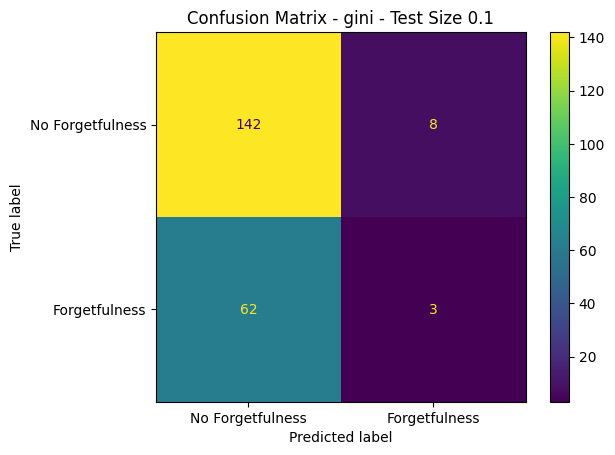

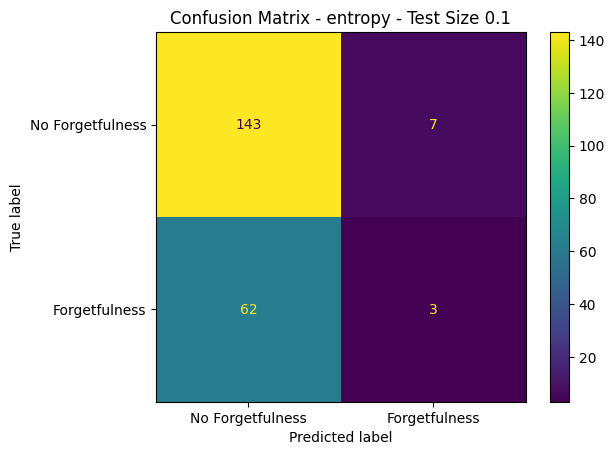

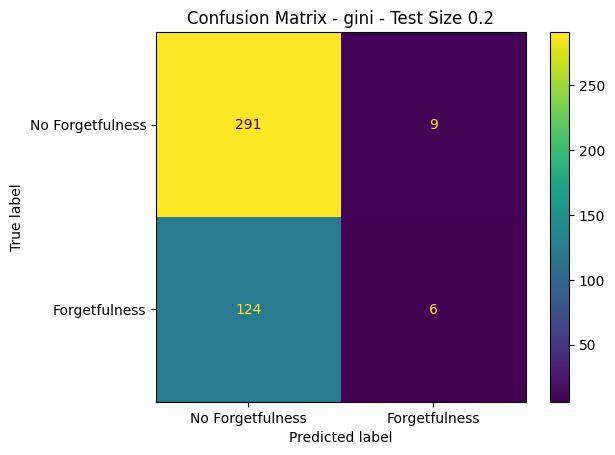

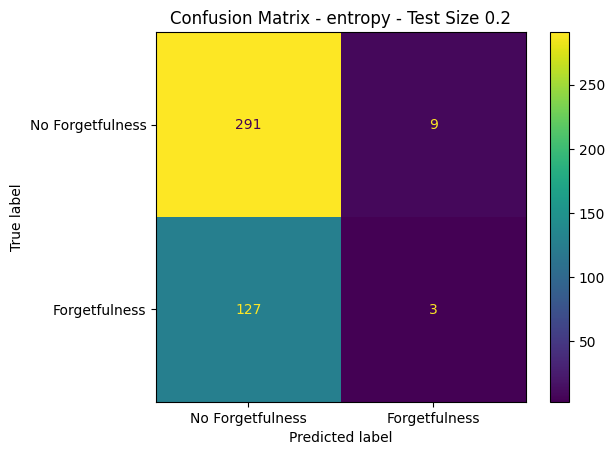

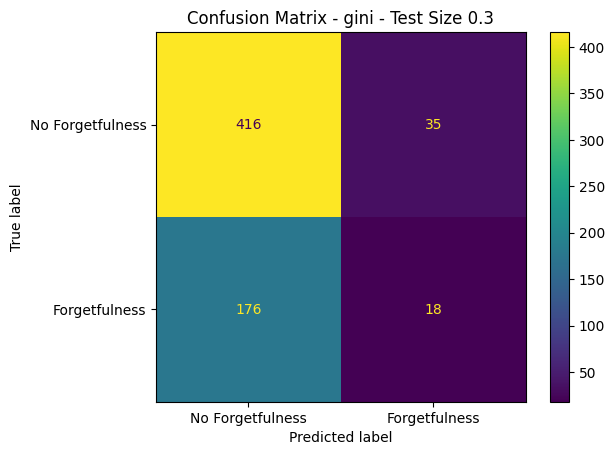

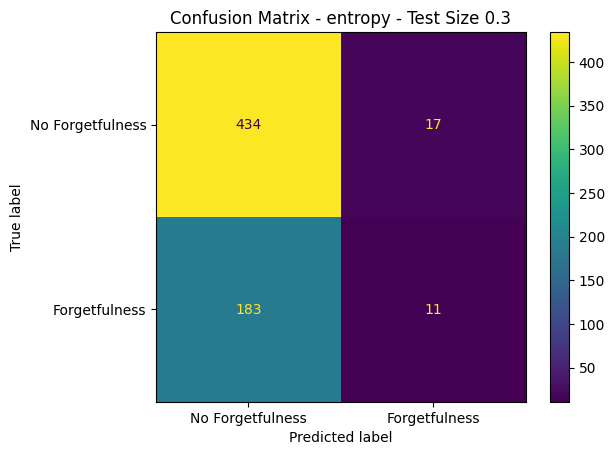

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for test_ratio in split_values:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_ratio,
        random_state=42,
        stratify=y
    )

    for criterion in ['gini', 'entropy']:
        model = DecisionTreeClassifier(
            criterion=criterion,
            random_state=42,
            max_depth=5
        )

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        cm = confusion_matrix(y_test, predictions)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['No Forgetfulness', 'Forgetfulness']
        )

        disp.plot()
        plt.title(f'Confusion Matrix - {criterion} - Test Size {test_ratio}')
        plt.show()

The confusion matrices above show the performance of the Decision Tree models using both Entropy and Gini across different data splits (0.1, 0.2, 0.3).

In general, the models correctly classify a large number of "No Forgetfulness" cases, indicating strong performance on the majority class.

However, there are noticeable misclassifications in the "Forgetfulness" class, where some cases are predicted as "No Forgetfulness", This suggests that the model has more difficulty detecting forgetfulness cases.

Across all splits, both Entropy and Gini provide consistent results, with slight variations depending on the test size. In some cases, Gini achieves more balanced predictions, while Entropy performs better in others.

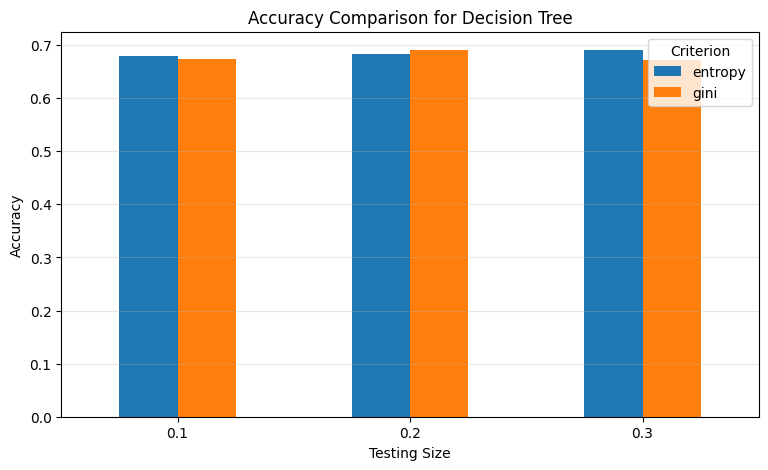

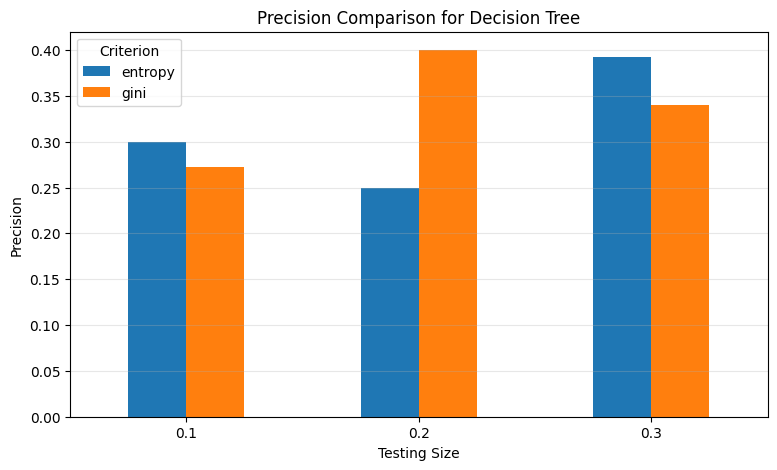

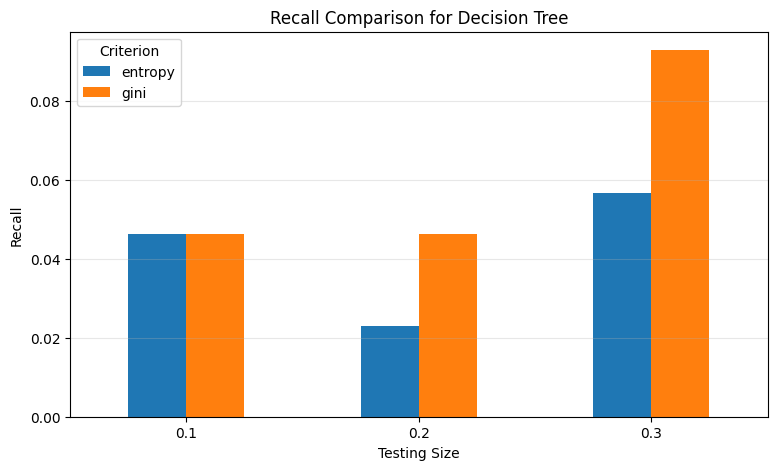

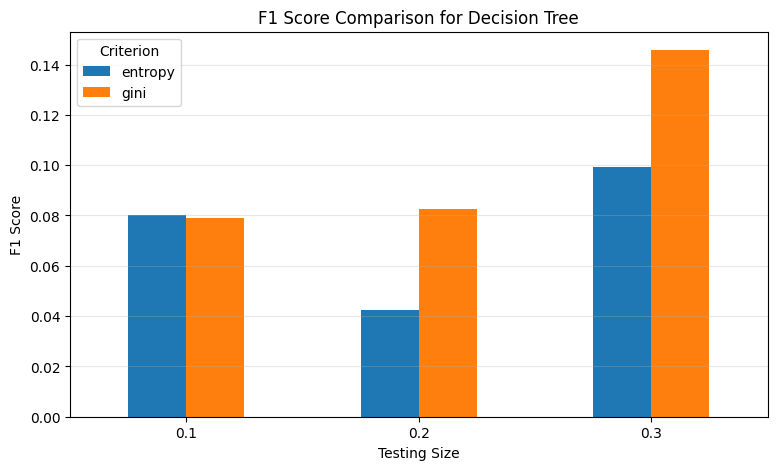

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    comparison = classification_results.pivot(
        index='Testing Size',
        columns='Criterion',
        values=metric
    )

    comparison.plot(kind='bar', figsize=(9, 5), rot=0)
    plt.title(metric + ' Comparison for Decision Tree')
    plt.xlabel('Testing Size')
    plt.ylabel(metric)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Here, we created comparison tables for

*   Accuracy
*   Precision
*   Recall
*   F1 score

to clearly see how each model performed with different splits





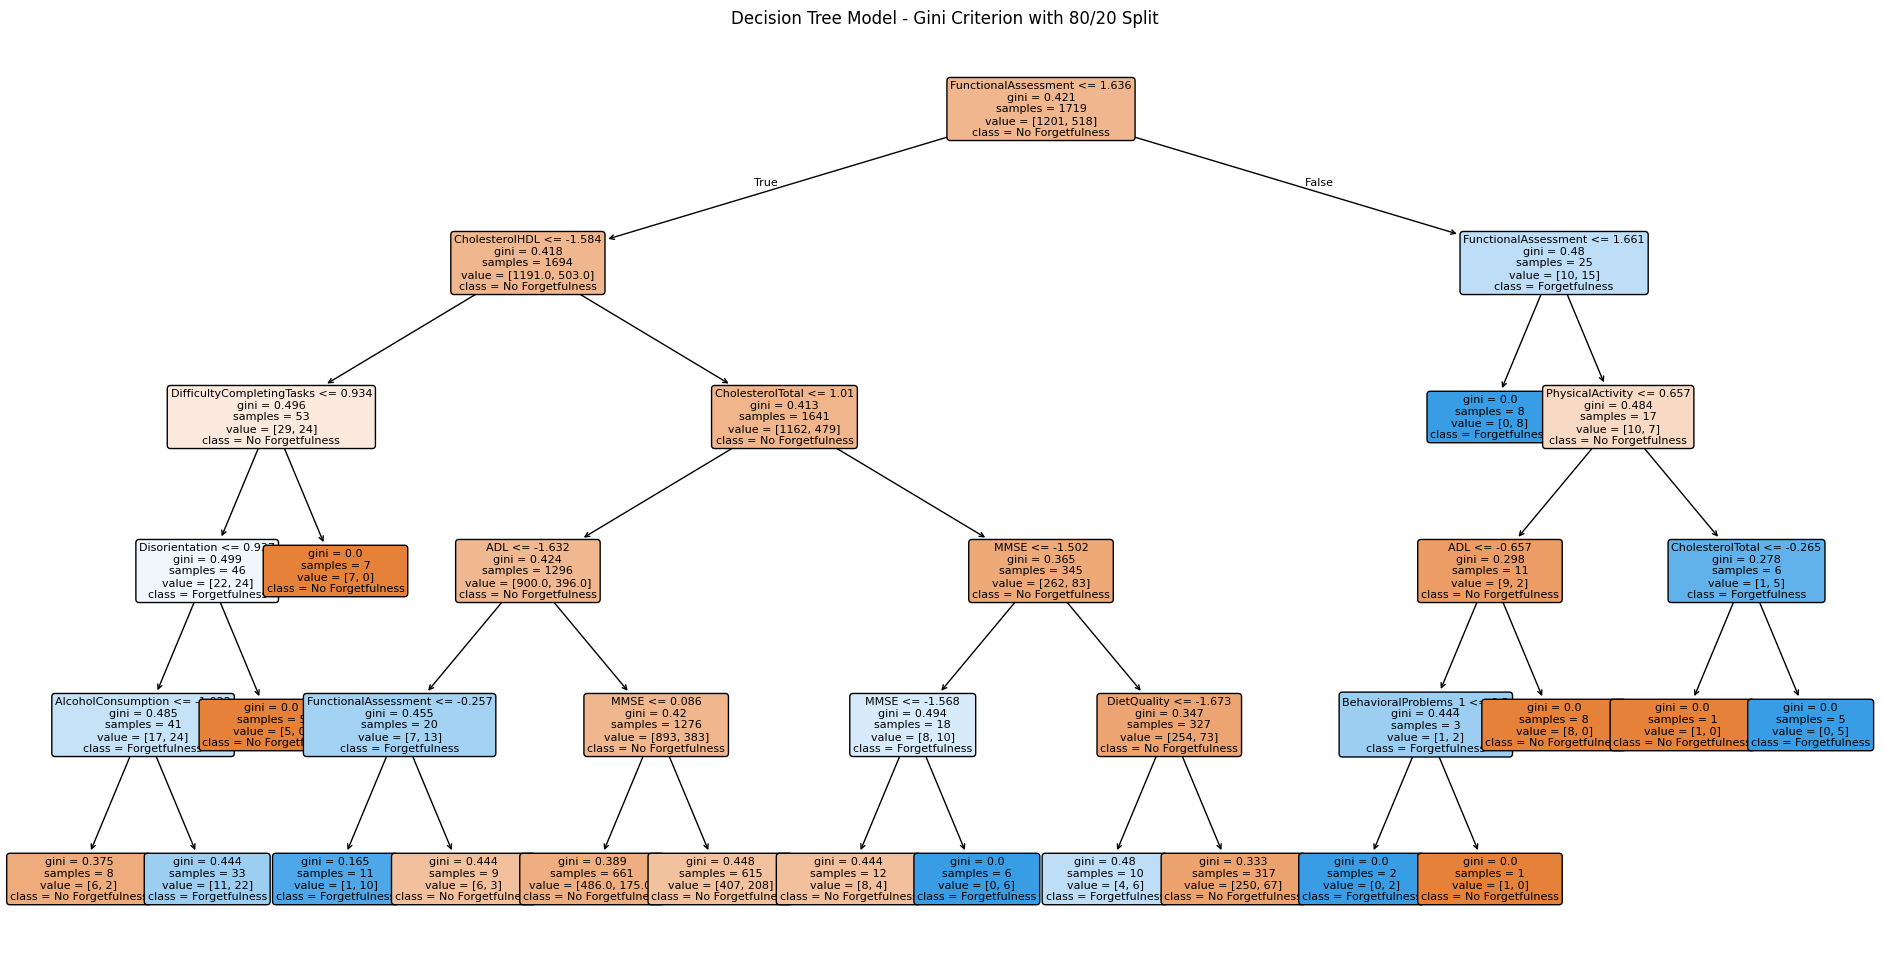

In [10]:
best_tree = gini_models[0.20]

plt.figure(figsize=(24, 12))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=['No Forgetfulness', 'Forgetfulness'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Decision Tree Model - Gini Criterion with 80/20 Split')
plt.show()

in this step, we selected the best decision tree model using the Gini criterion with a (80/20 split ) , then visualized the tree to better understand how the model works in makes decisions and which features are most important.

We can see that some features appear at higher levels in the tree, which means they have a stronger impact on the prediction.

In [11]:
best_row = classification_results.sort_values('F1 Score', ascending=False).iloc[0]

print('CLASSIFICATION CONCLUSION')
print('=' * 50)
print(f"Best criterion: {best_row['Criterion']}")
print(f"Best testing size: {best_row['Testing Size']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"F1 Score: {best_row['F1 Score']:.4f}")

print('\nThe Decision Tree model was used to classify whether the patient has forgetfulness or not.')
print('Both Gini and Entropy were tested with three different train/test partitions.')
print('The best model was selected based on the highest F1 Score because it balances precision and recall.')

CLASSIFICATION CONCLUSION
Best criterion: gini
Best testing size: 0.3
Accuracy: 0.6729
F1 Score: 0.1457

The Decision Tree model was used to classify whether the patient has forgetfulness or not.
Both Gini and Entropy were tested with three different train/test partitions.
The best model was selected based on the highest F1 Score because it balances precision and recall.


In this part, we compared the Decision Tree models to find the best one. The results were sorted using the F1 Score since it balances precision and recall. After that, we selected the best model and displayed its details, including the criterion, testing size, accuracy, and F1 Score. This helps us choose the most suitable model for predicting forgetfulness.

## Clustering- Evaluation and Comparison



In this section, we applied K-Means clustering and evaluated different K values using the Elbow Method and Silhouette Score. We also used PCA to visualize the clusters and analyzed the relationship between clusters and forgetfulness.

### Data Preparation

In [12]:
cluster_data = df.drop(columns=[target_col])

scaler = StandardScaler()
scaled_cluster_data = scaler.fit_transform(cluster_data)

print('Scaled clustering data shape:', scaled_cluster_data.shape)

Scaled clustering data shape: (2149, 45)


In this step, we prepared the data for clustering by removing the target column, since clustering does not use labels. Then, we scaled the data using StandardScaler so all features have the same range. This is important because K-Means relies on distance, and scaling prevents larger values from affecting the results more than others.

### Elbow Method

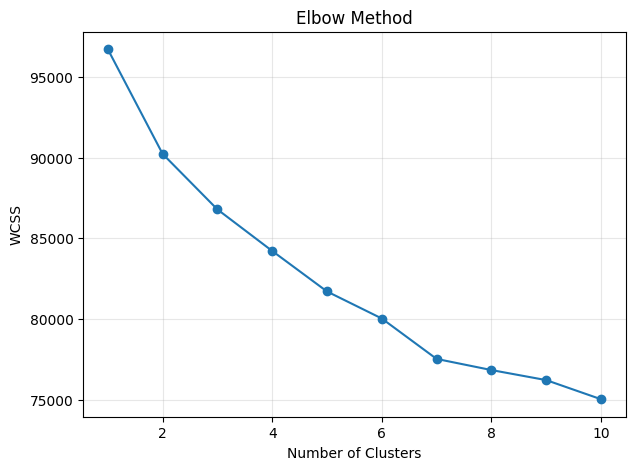

In [13]:
wcss = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_cluster_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(alpha=0.3)
plt.show()

In this part, we used the Elbow Method to choose a suitable number of clusters. We tested different K values and calculated WCSS for each one. Then, we plotted the results to find the point where the curve starts to slow down, which helps us decide the best number of clusters.

###  Silhouette Score

In [14]:
silhouette_results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_cluster_data)

    score = silhouette_score(scaled_cluster_data, labels)

    silhouette_results.append({
        'Number of Clusters': k,
        'Silhouette Score': score
    })

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

,Number of Clusters,Silhouette Score
0,2,0.067006
1,3,0.068010
2,4,0.062747
3,5,0.064168
4,6,0.063252
5,7,0.060495
6,8,0.041616
7,9,0.045269
8,10,0.036453


In this step, we calculated the silhouette score for different K values to evaluate the quality of the clusters. A higher score means better separation between clusters. Then, we stored the results in a DataFrame to make them easier to compare

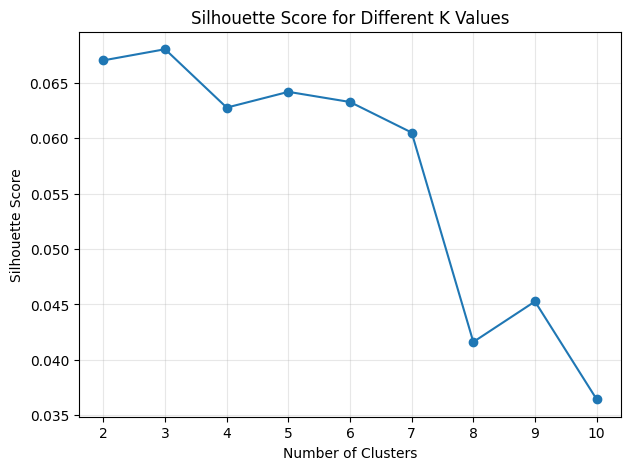

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(
    silhouette_df['Number of Clusters'],
    silhouette_df['Silhouette Score'],
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(alpha=0.3)
plt.show()

In this part, we plotted the silhouette scores to compare different K values visually. The graph makes it easier to see which K gives the best result by looking at the highest point, which supports our final choice of clusters.

Based on both the Elbow Method and Silhouette Score, the best number of clusters is K = 3.
The Elbow plot shows a clear slowdown in improvement after K = 3, and the Silhouette Score reaches its highest value at K = 3.
Therefore, K = 3 was selected as the optimal number of clusters.

### Comparison of K Values

In [16]:
comparison_results = []

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_cluster_data)

    silhouette_avg = silhouette_score(scaled_cluster_data, labels)
    wcss = kmeans.inertia_

    comparison_results.append({
        "K": k,
        "Average Silhouette": silhouette_avg,
        "WCSS": wcss
    })

comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)

,K,Average Silhouette,WCSS
0,2,0.067006,90228.079751
1,3,0.068010,86791.712967
2,4,0.062747,84221.031422


### Comparison of Different K Values

| K | Average Silhouette | WCSS |
|---|-------------------|------|
| 2 | 0.067006            | 90228.079751 |
| 3 | 0.068010           | 86791.712967|
| 4 | 0.062747            | 84221.031422 |

The table shows that K = 3 has the highest silhouette score. However, the silhouette values are relatively low, indicating that the clusters are not strongly separated.

### Interpretation of Results

- **K = 2:** The clusters are more general and less detailed. The silhouette score is moderate, but grouping is too broad.

- **K = 3:** This value provides the best balance among the tested values. However, the silhouette score is relatively low, indicating that the clusters are not strongly separated and there is some overlap between them.

- **K = 4:** The clusters become more fragmented, and the silhouette score decreases, indicating weaker separation.

### Best K Selection

Based on the comparison:
- K = 3 has the highest silhouette score.
- The Elbow Method also suggests K = 3.
- Therefore, using the majority rule, the optimal number of clusters is **K = 3**.

In [17]:
best_k = 3
print("Best number of clusters:", best_k)

Best number of clusters: 3


### Visualization for Each K

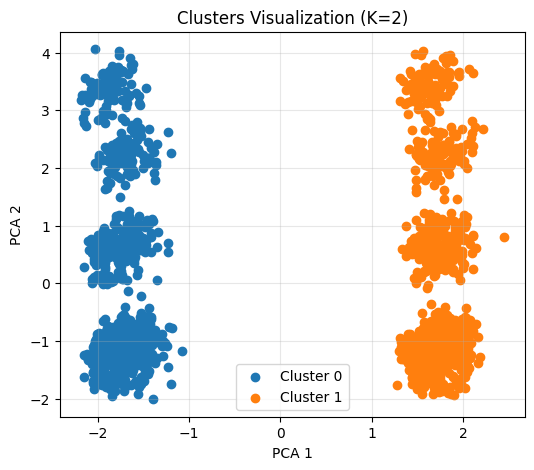

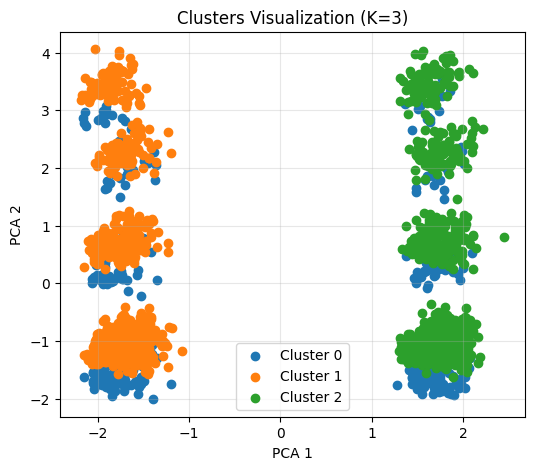

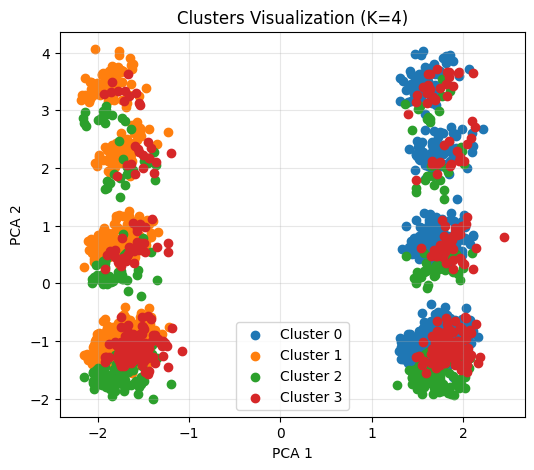

In [18]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_cluster_data)

    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(scaled_cluster_data)

    plt.figure(figsize=(6,5))

    for cluster in range(k):
        points = pca_data[labels == cluster]
        plt.scatter(points[:,0], points[:,1], label=f'Cluster {cluster}')

    plt.title(f'Clusters Visualization (K={k})')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Visualization Interpretation

- For K = 2, clusters are broad and overlapping.
- For K = 3, clusters are partially overlapping, which indicates that the separation between clusters is not very strong.
- For K = 4, clusters become more scattered with less clear boundaries.

This confirms that K = 3 is the most suitable choice.

### Final K-Means Model (k=3)

In [19]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_cluster_data)

df['Cluster'] = cluster_labels

print(df['Cluster'].value_counts())

Cluster
2    915
1    897
0    337
Name: count, dtype: int64


In this step, we built the final K-Means model using the optimal K value and assigned each data point to a cluster.

###  PCA Visualization

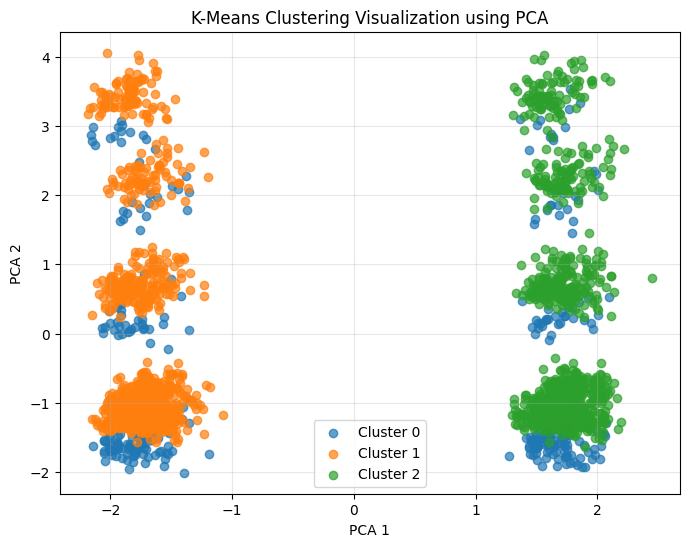

In [20]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_cluster_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_points = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(
        cluster_points['PCA1'],
        cluster_points['PCA2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.title('K-Means Clustering Visualization using PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In this part, we used PCA to reduce the data into two components so we could visualize the clusters in a 2D plot. This makes it easier to see how the clusters are distributed and whether they are clearly separated or overlapping

The PCA plot shows that the clusters are partially separated with some overlap. This indicates that while K-Means was able to group similar records, the separation is not very strong this indicates that the clustering model captured meaningful patterns in the data.

Forgetfulness,0,1
Cluster,,
0,67.36,32.64
1,69.45,30.55
2,71.15,28.85


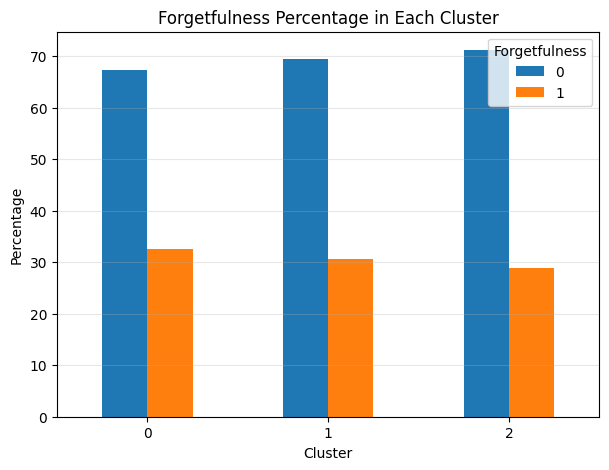

In [21]:
cluster_forgetfulness = pd.crosstab(
    df['Cluster'],
    df[target_col],
    normalize='index'
) * 100

display(cluster_forgetfulness.round(2))

cluster_forgetfulness.plot(kind='bar', figsize=(7, 5), rot=0)

plt.title('Forgetfulness Percentage in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.legend(title='Forgetfulness')
plt.grid(axis='y', alpha=0.3)
plt.show()

In this step, we analyzed the relationship between clusters and the target variable (Forgetfulness).
The results show that all clusters have similar distributions of forgetfulness, with slight differences between them.

Cluster 2 has the lowest percentage of forgetfulness, while Cluster 0 has the highest.
However, the differences are not very large, which indicates that the clusters are not strongly separated based on the target variable.

This suggests that while K-Means identified patterns in the data, these patterns are not highly correlated with forgetfulness.

### Clustering Conclusion

K-Means clustering was applied after scaling the data. The optimal number of clusters was K = 3 based on both Elbow Method and Silhouette Score.

The PCA visualization showed partial separation between clusters, indicating relatively weak clustering quality

Overall,clustering revealed general patterns in the data, but these patterns are not clearly distinguishable, This indicates that the dataset may not have clear natural groupings based on the given features.

# ⁠ ⁠Findings and Discussion

In this section, we discuss the results obtained from both classification and clustering techniques and compare their effectiveness in solving the problem.

Classification (Decision Tree)

The Decision Tree model was used to predict the target variable (Forgetfulness). Based on the evaluation metrics (accuracy, precision, recall, and F1-score), the model achieved moderate performance across different train/test splits.

From the results, accuracy values were relatively consistent across splits, indicating that the model is stable. However, the recall and F1-score values were low, suggesting that the model has difficulty correctly identifying the “Forgetfulness” class. This is also supported by the confusion matrix, where several cases of forgetfulness were misclassified as “No Forgetfulness”.

The tree structure shows that multiple features contribute to the prediction, including health and lifestyle-related variables. This confirms that forgetfulness is influenced by a combination of factors rather than a single variable.

One major advantage of the Decision Tree is its interpretability, as it clearly explains how decisions are made through a sequence of rules.

⸻

Clustering (K-Means)

For clustering, K-Means was applied using different values of K.

•⁠  ⁠When K = 2, the clusters were too general and overlapping
•⁠  ⁠When K = 3, the separation between clusters improved
•⁠  ⁠When K = 4, the clusters became more fragmented and less stable

Based on the Elbow Method and Silhouette Score, K = 3 was selected as the optimal number of clusters.

However, when comparing the clusters with the target variable (Forgetfulness), no strong relationship was observed. The distribution of the target variable across clusters was similar, indicating that clustering did not clearly separate individuals based on forgetfulness.

⸻

Comparison Between the Two Methods

The Decision Tree model performed better for this task because it directly predicts the target variable and provides interpretable results.

In contrast, clustering is an unsupervised method and does not use the target variable during training. Therefore, it is more suitable for discovering hidden patterns rather than making predictions.

⸻

Key Insights

•⁠  ⁠Forgetfulness is influenced by multiple features rather than a single factor
•⁠  ⁠The classification model shows stable accuracy but struggles with minority class detection
•⁠  ⁠Clustering reveals general data groupings but does not strongly separate the target classes
•⁠  ⁠The dataset contains patterns, but they are not sharply defined

⸻

Relation to the Research Paper

The findings are consistent with the research paper, where classification methods showed better performance in prediction tasks, while clustering was mainly useful for exploratory analysis.

⸻

Conclusion

Overall, the Decision Tree is the most suitable model for this problem due to its ability to provide both predictions and interpretability.

K-Means clustering contributed to understanding the data structure but was not sufficient for accurately identifying forgetfulness.

Combining both approaches provided a more comprehensive understanding of the dataset.

# References

[1] R. Saini and K. P. Sharma, "Alzheimer's Disease Detection and Classification: A Survey," in 2024 First International Conference on Pioneering Developments in Computer Science & Digital Technologies (IC2SDT), Delhi, India, 2024, pp. 604-609, doi: 10.1109/IC2SDT62152.2024.10695982.